# Netflix Content Analysis
Exploratory Data Analysis on Netflix's movies and TV shows catalog — 
uncovering trends in content type, growth over years, country-wise 
distribution, and duration patterns.

**Dataset:** Netflix Titles (Kaggle)
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('netflix_titles.csv')

In [35]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [36]:
print(df.shape)

(8807, 11)


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  description   8807 non-null   str  
dtypes: int64(1), str(10)
memory usage: 757.0 KB


In [38]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
description        0
dtype: int64

In [39]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,In a city of coaching centers known to train I...


In [40]:
df['director']=df['director'].fillna('UNKNOWN', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_7448\2862125854.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director']=df['director'].fillna('UNKNOWN', inplace=True)


In [41]:
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [42]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])


In [43]:
print(df.duplicated().sum())   # kitne exact duplicate rows hain, pehle check karo
df = df.drop_duplicates()

0


In [44]:
df = df.drop_duplicates()

In [45]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [46]:
df.isnull().sum()   # ab sab 0 aana chahiye (director, cast, country ke alawa jo Unknown ho gaye)
df.shape             # dekho kitni rows bachi


(8790, 11)

In [47]:
df['year_added'] = df['date_added'].dt.year

In [48]:
df['date_added'].dt.year

0       2021
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2019
8803    2019
8804    2019
8805    2020
8806    2019
Name: date_added, Length: 8790, dtype: int32

In [49]:
df['duration_number'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

In [50]:

df[['duration', 'duration_number', 'duration_unit']].head()

,duration,duration_number,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


In [51]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [52]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

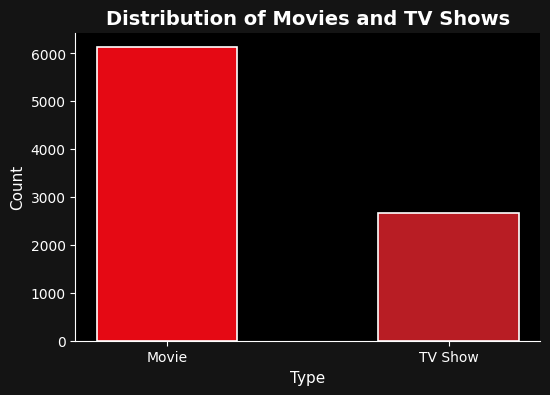

In [53]:
plt.style.use('dark_background')
plt.figure(figsize=(6, 4), facecolor='#141414')

type_counts = df['type'].value_counts()
plt.bar(type_counts.index, type_counts.values, color=['#E50914', '#B81D24'], edgecolor='white', linewidth=1.2, width=0.5)

plt.title('Distribution of Movies and TV Shows', color='white', fontsize=14, fontweight='bold')
plt.xlabel('Type', color='white', fontsize=11)
plt.ylabel('Count', color='white', fontsize=11)
plt.xticks(color='white')
plt.yticks(color='white')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

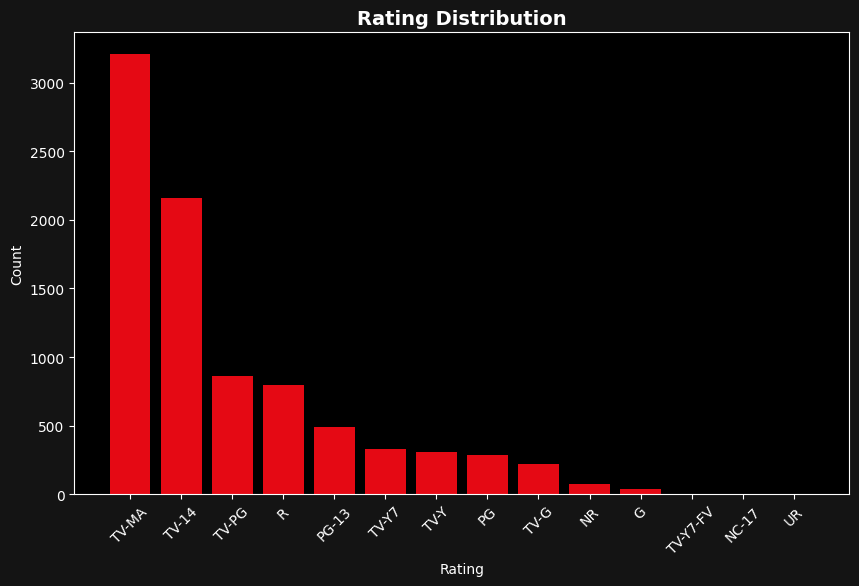

In [54]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10, 6), facecolor='#141414')
plt.bar(rating_counts.index, rating_counts.values, color='#E50914')

plt.title('Rating Distribution', color='white', fontsize=14, fontweight='bold')
plt.xlabel('Rating', color='white')
plt.ylabel('Count', color='white')
plt.xticks(color='white', rotation=45)   # rotation isliye taaki labels overlap na ho (zyada categories hain)
plt.yticks(color='white')

plt.show()

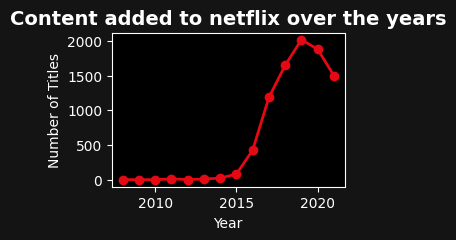

In [55]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(3,2), facecolor='#141414')
plt.plot(year_counts.index, year_counts.values, color='#E50914', marker='o', linewidth=2)

plt.title('Content added to netflix over the years', color='white', fontsize=14, fontweight='bold')
plt.xlabel('Year', color='white')
plt.ylabel('Number of Titles', color='white')
plt.xticks(color='white')
plt.yticks(color='white')

plt.show()

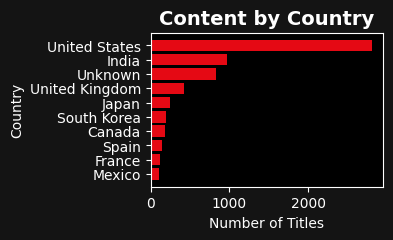

In [56]:
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(3,2), facecolor='#141414')
plt.barh(country_counts.index, country_counts.values, color='#E50914')

plt.title('Content by Country', color='white', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', color='white')
plt.ylabel('Country', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.gca().invert_yaxis()

plt.show()

In [57]:
movie_df = df[df['type'] == 'Movie']

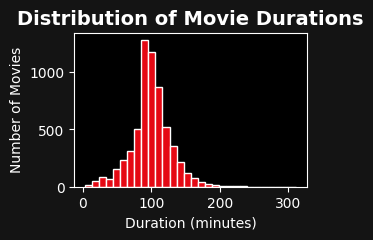

In [58]:
plt.figure(figsize=(3,2), facecolor='#141414')
plt.hist(movie_df['duration_number'], bins=30, color='#E50914', edgecolor='white')

plt.title('Distribution of Movie Durations', color='white', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)', color='white')
plt.ylabel('Number of Movies', color='white')
plt.xticks(color='white')
plt.yticks(color='white')

plt.show()

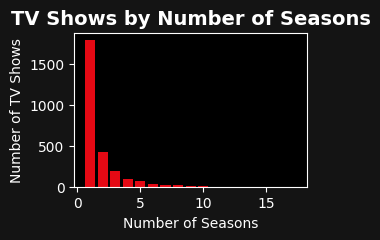

In [59]:
tv_df = df[df['type'] == 'TV Show']
season_counts = tv_df['duration_number'].value_counts().sort_index()

plt.figure(figsize=(3,2), facecolor='#141414')
plt.bar(season_counts.index, season_counts.values, color='#E50914')

plt.title('TV Shows by Number of Seasons', color='white', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons', color='white')
plt.ylabel('Number of TV Shows', color='white')
plt.xticks(color='white')
plt.yticks(color='white')

plt.show()

### Insight: Movie vs TV Show Distribution
- Netflix's catalog is dominated by Movies (~70%), with TV Shows making up a smaller share (~30%).

### Insight: Content Growth Over the Years
- Content additions peaked around [saal jo tumhare chart me highest tha], suggesting Netflix's biggest catalog expansion happened during that period.

### Insight: Top Countries
- The United States leads content production, followed by [doosra country jo tumhare chart me tha], showing Netflix's US-centric content strategy with growing international presence.

### Insight: Movie Duration
- Most movies fall in the 90-120 minute range, aligning with standard theatrical/streaming runtime conventions.

### Insight: TV Show Seasons
- The majority of TV Shows have only 1 season, indicating Netflix favors limited series or tests new shows before renewing them.